In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\javier.sdiaz\Proyecto ML_2025\data\processed\datos_procesados.csv", sep=",")
df

,Temp_amb,Dir_viento,Vel_viento,Energia,Potencia,Oil_Temp,cosPhi,Frecuencia,Temp_int,Q,Año,Estacion,Rad_prom,HeatsinkTemp_prom,Idc_total,V_total,Minuto_sin,Hora_sin,Dia_sin,Mes_sin
0,11.346512,222.558422,2.611367,26.931747,0.0,26.079072,0.0,49.960499,20.329768,0.0,2022,1,0.0,17.075259,0.0,1146.307697,0.000000e+00,0.000000,0.781831,5.000000e-01
1,11.300000,223.087589,2.582713,0.000000,0.0,25.479083,0.0,49.959999,20.179770,0.0,2022,1,0.0,16.883596,0.0,1147.522942,1.000000e+00,0.000000,0.781831,5.000000e-01
2,11.306667,224.893609,2.640629,0.000000,0.0,24.879095,0.0,49.959999,20.029773,0.0,2022,1,0.0,16.691933,0.0,1150.385870,5.665539e-16,0.000000,0.781831,5.000000e-01
3,11.293333,223.534547,2.808005,0.000000,0.0,24.279182,0.0,49.959999,19.879776,0.0,2022,1,0.0,16.506316,0.0,1153.091744,-1.000000e+00,0.000000,0.781831,5.000000e-01
4,11.259853,230.927235,3.147298,0.000000,0.0,23.745968,0.0,49.960503,19.741495,0.0,2022,1,0.0,16.404334,0.0,1150.639247,0.000000e+00,0.258819,0.781831,5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105211,4.145149,223.663976,5.285611,740.750000,0.0,8.529718,0.0,50.000000,10.085310,0.0,2024,1,0.0,7.151938,0.0,1145.415732,-1.000000e+00,-0.500000,0.433884,-2.449294e-16
105212,4.245148,219.700928,5.490529,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,0.000000e+00,-0.258819,0.433884,-2.449294e-16
105213,4.376957,222.824833,5.048825,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,1.000000e+00,-0.258819,0.433884,-2.449294e-16
105214,4.493333,220.484426,4.876356,740.750000,0.0,8.329723,0.0,50.000000,10.117952,0.0,2024,1,0.0,7.165451,0.0,1145.233798,5.665539e-16,-0.258819,0.433884,-2.449294e-16


In [3]:
# Definir las variables predictoras (X) y la variable objetivo (y)
X = df.drop(columns=['Temp_int'])  # Variables predictoras
y = df['Temp_int']  # Variable objetivo

# Dividir los datos en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertir los datos en un formato adecuado para XGBoost (DMatrix)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

# Establecer los parámetros del modelo XGBoost
params = {
    'objective': 'reg:squarederror',  # Tarea de regresión
    'eval_metric': 'rmse',  # Evaluar el error cuadrático medio
    'max_depth': 6,  # Profundidad máxima de los árboles
    'learning_rate': 0.1,  # Tasa de aprendizaje
    'n_estimators': 100,  # Número de árboles
    'random_state': 42  # Fijar la semilla para reproducibilidad
}

# Entrenar el modelo XGBoost
xgb_model = xgb.train(params, dtrain, num_boost_round=100)

# Hacer predicciones sobre el conjunto de prueba
y_pred = xgb_model.predict(dval)

# Evaluar el modelo
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

# Mostrar las métricas de evaluación
print(f"Evaluación del modelo XGBoost:")
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"R² (Coeficiente de Determinación): {r2:.2f}")



c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [17:49:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


Evaluación del modelo XGBoost:
MAE (Error Absoluto Medio): 0.59
RMSE (Raíz del Error Cuadrático Medio): 0.97
R² (Coeficiente de Determinación): 0.99


In [4]:
X_test = pd.read_csv(r"C:\Users\javier.sdiaz\Proyecto ML_2025\data\processed\Test_Temp_int_proc.csv")
X_test



,Temp_amb,Dir_viento,Vel_viento,Energia,Potencia,Oil_Temp,cosPhi,Frecuencia,Q,Año,Estacion,Rad_prom,HeatsinkTemp_prom,Idc_total,V_total,Minuto_sin,Hora_sin,Dia_sin,Mes_sin
0,4.693333,223.434619,5.776876,13.123160,0.0,8.329723,0.0,50.000000,0.0,2025,1,0.0,7.165451,0.0,1145.233798,0.000000e+00,0.000000,7.818315e-01,0.500000
1,4.778227,230.540226,6.300436,0.000000,0.0,8.129727,0.0,50.000000,0.0,2025,1,0.0,7.166667,0.0,1147.406089,1.000000e+00,0.000000,7.818315e-01,0.500000
2,4.701775,236.717029,6.500883,0.000000,0.0,7.929731,0.0,49.999846,0.0,2025,1,0.0,7.166668,0.0,1139.181287,5.665539e-16,0.000000,7.818315e-01,0.500000
3,4.641534,237.076536,6.044294,0.000000,0.0,7.734364,0.0,49.997872,0.0,2025,1,0.0,7.174754,0.0,1136.409406,-1.000000e+00,0.000000,7.818315e-01,0.500000
4,4.613334,236.621290,5.554435,0.000000,0.0,7.593590,0.0,49.995373,0.0,2025,1,0.0,7.193001,0.0,1135.361969,0.000000e+00,0.258819,7.818315e-01,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5660,2.141719,16.335910,2.084161,5388.750000,0.0,18.035745,0.0,49.993377,0.0,2025,1,0.0,11.696564,0.0,1146.761841,0.000000e+00,-0.258819,-9.797174e-16,0.866025
5661,2.146475,26.110985,2.236413,5388.750000,0.0,17.419501,0.0,49.990906,0.0,2025,1,0.0,11.555946,0.0,1146.418001,1.000000e+00,-0.258819,-9.797174e-16,0.866025
5662,1.981918,29.292776,2.323841,5388.750000,0.0,16.859487,0.0,49.990002,0.0,2025,1,0.0,11.397732,0.0,1143.510209,5.665539e-16,-0.258819,-9.797174e-16,0.866025
5663,1.880056,31.918149,2.237500,5378.357727,0.0,16.309506,0.0,49.990002,0.0,2025,1,0.0,11.239403,0.0,1142.701660,-1.000000e+00,-0.258819,-9.797174e-16,0.866025


In [6]:
# Convertir los datos de prueba a DMatrix
dtest = xgb.DMatrix(X_test)

# Hacer predicciones sobre el conjunto de prueba
y_test_pred = xgb_model.predict(dtest)



In [7]:
# Crear un DataFrame con las predicciones
resultados = pd.DataFrame({
    
    'Temp_amb_int': y_test_pred
})

# Guardar las predicciones
resultados.to_csv("predicciones_xgb_Temp_int.csv", index=False)


In [8]:
# Cargar los datos reales de test
df_real = pd.read_csv("Datos_Reales_Temp_int.csv")
df_real.set_index(df_real.index, inplace=True)

y_real = df_real['Temp_int']


In [9]:
y_test_pred

array([10.477544, 10.611823, 10.577617, ..., 13.648334, 13.388893,
       12.464141], dtype=float32)

In [10]:
y_real

0       10.117952
1       10.142951
2       10.167950
3       10.192950
4       10.217949
          ...    
5660    13.108009
5661    12.933014
5662    12.758019
5663    12.583025
5664    12.408030
Name: Temp_int, Length: 5665, dtype: float64

In [11]:
mae = mean_absolute_error(y_real, y_test_pred)
print(f"Error Absoluto Medio (MAE): {mae}")

Error Absoluto Medio (MAE): 1.241025103431994


In [12]:
# Calcular R²
r2 = r2_score(y_real, y_test_pred)
print(f"Coeficiente de Determinación (R²): {r2}")

Coeficiente de Determinación (R²): 0.7078867546003252


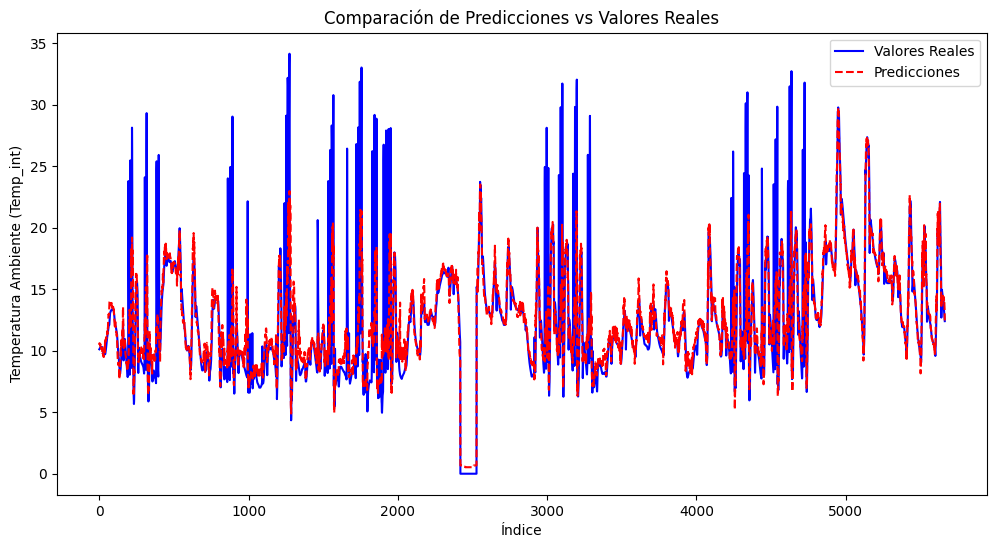

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(y_real, label="Valores Reales", color='blue')
plt.plot(y_test_pred, label="Predicciones", color='red', linestyle='--')
plt.xlabel("Índice")
plt.ylabel("Temperatura Ambiente (Temp_int)")
plt.title("Comparación de Predicciones vs Valores Reales")
plt.legend()
plt.show()


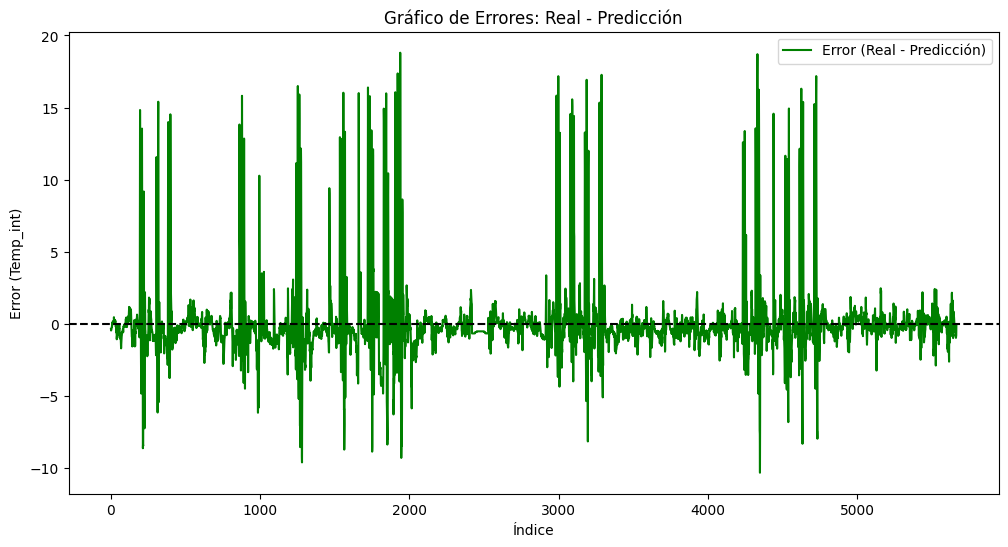

In [14]:
plt.figure(figsize=(12, 6))

# Graficar las diferencias entre los valores reales y las predicciones
errors = y_real - y_test_pred
plt.plot(errors, label="Error (Real - Predicción)", color='green')
plt.axhline(0, color='black', linestyle='--')  # Línea de 0 para referencia
plt.xlabel("Índice")
plt.ylabel("Error (Temp_int)")
plt.title("Gráfico de Errores: Real - Predicción")
plt.legend()
plt.show()


Epoch 1/50


c:\Users\javier.sdiaz\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2631/2631 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 572.4841 - val_loss: 28.0357
Epoch 2/50
2631/2631 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 59.5495 - val_loss: 12.8827
Epoch 3/50
2631/2631 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 32.6677 - val_loss: 4.1362
Epoch 4/50
2631/2631 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 22.8370 - val_loss: 5.3907
Epoch 5/50
2631/2631 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 13.5136 - val_loss: 4.1575
Epoch 6/50
2631/2631 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 12.3965 - val_loss: 6.7356
Epoch 7/50
2631/2631 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 13.0499 - val_loss: 3.6175
Epoch 8/50
2631/2631 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 7.6447 - val_loss: 14.3975
Epoch 9/50
2631/2631 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 5.5291 - val_loss: 10.2971
Epoch 10/50
2631/2631 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 7.2473 - val_loss: 4.6819
Epoch 11/50
2631/2631 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 4.8882 - val_loss: 2.7321
Epoch 12/50
2631/2631 ━━━━━━━

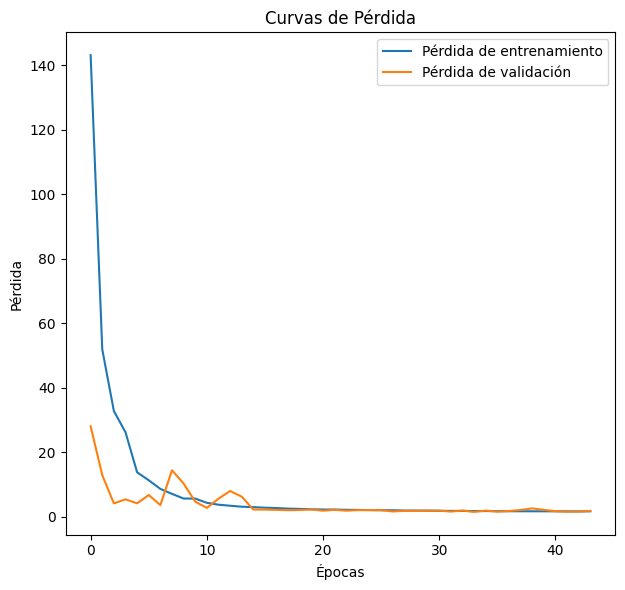

In [16]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Crear el modelo de la red neuronal
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Configurar EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenar el modelo con EarlyStopping
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping])

# Hacer predicciones
y_pred = model.predict(X_test)

# Graficar las curvas de entrenamiento y validación
plt.figure(figsize=(12, 6))

# Curva de pérdida de entrenamiento vs validación
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Curvas de Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()



plt.tight_layout()
plt.show()



In [ ]:
from sklearn.metrics import r2_score

# Calcular el R²
r2 = r2_score(y_real, y_pred)

# Mostrar el valor de R²
print(f"R² (Coeficiente de Determinación): {r2:.2f}")


R² (Coeficiente de Determinación): 0.65
